<a href="https://colab.research.google.com/github/vishal786-commits/machine-learning-journey/blob/main/ml-projects/NLP-FlipItNews/NLP_FlipItNews_Vishal_Gopalkrishna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlipItNews: News Article Classification Using Natural Language Processing

### NLP-Based Multi-Class Classification of News Articles

**Case Study:** FlipItNews  
**Domain:** Natural Language Processing (NLP) & Machine Learning  
**Objective:** Categorize news articles into Politics, Technology, Sports, Business, and Entertainment

## Introduction

FlipItNews is a Gurugram-based company focused on transforming the way Indians consume and understand information related to finance, business, and capital markets.

The company aims to improve financial literacy and awareness by using Artificial Intelligence (AI) and Machine Learning (ML) to enable smarter information discovery and contextual engagement.

As the volume of digital news continues to grow, automatically organizing news articles into meaningful categories becomes increasingly important. Natural Language Processing (NLP) provides the tools required to analyze and extract meaningful information from textual data.

In this case study, we will use NLP and Machine Learning techniques to classify news articles into different categories such as:

- Politics
- Technology
- Sports
- Business
- Entertainment

The project will involve text preprocessing, feature extraction, multi-class classification, and comparison of multiple machine learning models.

## Problem Statement

FlipItNews has a large collection of news articles stored in its internal database. Manually categorizing these articles is time-consuming, difficult to scale, and may lead to inconsistencies.

The objective of this case study is to develop a **multi-class text classification system** that can automatically categorize a news article into its appropriate category based on its content.

The categories considered in this dataset are:

- Politics
- Technology
- Sports
- Business
- Entertainment

To accomplish this, Natural Language Processing techniques will be used to preprocess and transform the textual data into numerical features. Multiple Machine Learning classification algorithms will then be trained and evaluated to identify an effective model for this use case.

In [1]:
# Install gdown to download files from Google Drive
!pip -q install gdown

# Download the dataset
!gdown "https://drive.google.com/uc?id=1I3-pQFzbSufhpMrUKAROBLGULXcWiB9u"

# Import pandas
import pandas as pd

# Load the CSV file
df = pd.read_csv("flipitnews-data.csv")

# Display the first 5 rows
df.head()

Downloading...
From: https://drive.google.com/uc?id=1I3-pQFzbSufhpMrUKAROBLGULXcWiB9u
To: /content/flipitnews-data.csv
100% 5.06M/5.06M [00:00<00:00, 26.4MB/s]


,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...


In [2]:
# Check dimensions
print("Shape of dataset:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

# Display basic information
print("\nDataset Information:")
df.info()

Shape of dataset: (2225, 2)

Columns:
['Category', 'Article']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  2225 non-null   object
 1   Article   2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [3]:
df.head(10)

,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...
5,Politics,howard hits back at mongrel jibe michael howar...
6,Politics,blair prepares to name poll date tony blair is...
7,Sports,henman hopes ended in dubai third seed tim hen...
8,Sports,wilkinson fit to face edinburgh england captai...
9,Entertainment,last star wars not for children the sixth an...


In [4]:
df.isnull().sum()

,0
Category,0
Article,0


In [5]:
df["Category"].value_counts()

,count
Category,
Sports,511
Business,510
Politics,417
Technology,401
Entertainment,386


## Dataset Summary

The dataset contains **2,225 news articles** across two columns: `Category` and `Article`. Both columns contain **no missing values**, making the dataset suitable for further analysis and modeling.

The articles are distributed across five categories, with **Sports (511)** and **Business (510)** having the highest representation, while **Entertainment (386)** has the fewest articles. Technology accounts for **401 articles** and Politics for **417 articles**.

Overall, the dataset is reasonably distributed across the five categories, although Sports and Business have slightly more articles than the other categories.

In [8]:
# Display a few sample news articles from different categories

for category in df["Category"].unique():
    print(f"\n{'='*80}")
    print(f"Category: {category}")
    print(f"{'='*80}")

    article = df[df["Category"] == category]["Article"].iloc[0]
    print(article[:1000])


Category: Technology
tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also b

In [9]:
# Calculate article length in characters and words

df["Article_Char_Length"] = df["Article"].apply(len)
df["Article_Word_Length"] = df["Article"].apply(lambda x: len(x.split()))

print("Average article length (characters):", round(df["Article_Char_Length"].mean(), 2))
print("Average article length (words):", round(df["Article_Word_Length"].mean(), 2))

print("\nMinimum article length (words):", df["Article_Word_Length"].min())
print("Maximum article length (words):", df["Article_Word_Length"].max())

Average article length (characters): 2262.94
Average article length (words): 390.3

Minimum article length (words): 90
Maximum article length (words): 4492


In [10]:
# Average article length by category

df.groupby("Category")["Article_Word_Length"].agg(
    ["mean", "min", "max"]
).round(2)

,mean,min,max
Category,,,
Business,334.19,142,912
Entertainment,337.68,144,3570
Politics,461.19,90,4492
Sports,336.32,116,1671
Technology,507.36,165,3007


In [11]:
from collections import Counter
import re
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

# Combine all articles
all_text = " ".join(df["Article"].astype(str))

# Extract words
words = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())

# Remove stopwords
filtered_words = [word for word in words if word not in stop_words]

# Count word frequencies
word_counts = Counter(filtered_words)

# Display the 20 most common words
word_counts.most_common(20)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('said', 7255),
 ('mr', 3005),
 ('would', 2581),
 ('year', 2309),
 ('also', 2156),
 ('people', 2045),
 ('new', 1978),
 ('us', 1972),
 ('one', 1892),
 ('could', 1511),
 ('last', 1394),
 ('first', 1355),
 ('time', 1322),
 ('two', 1282),
 ('world', 1201),
 ('government', 1160),
 ('uk', 1115),
 ('years', 1003),
 ('best', 974),
 ('make', 945)]

In [12]:
# Number of unique words before and after removing stopwords

all_words = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())

unique_words = set(all_words)
unique_filtered_words = set(filtered_words)

print("Total word occurrences:", len(all_words))
print("Unique words:", len(unique_words))
print("Unique words after stopword removal:", len(unique_filtered_words))

Total word occurrences: 855598
Unique words: 27877
Unique words after stopword removal: 27728


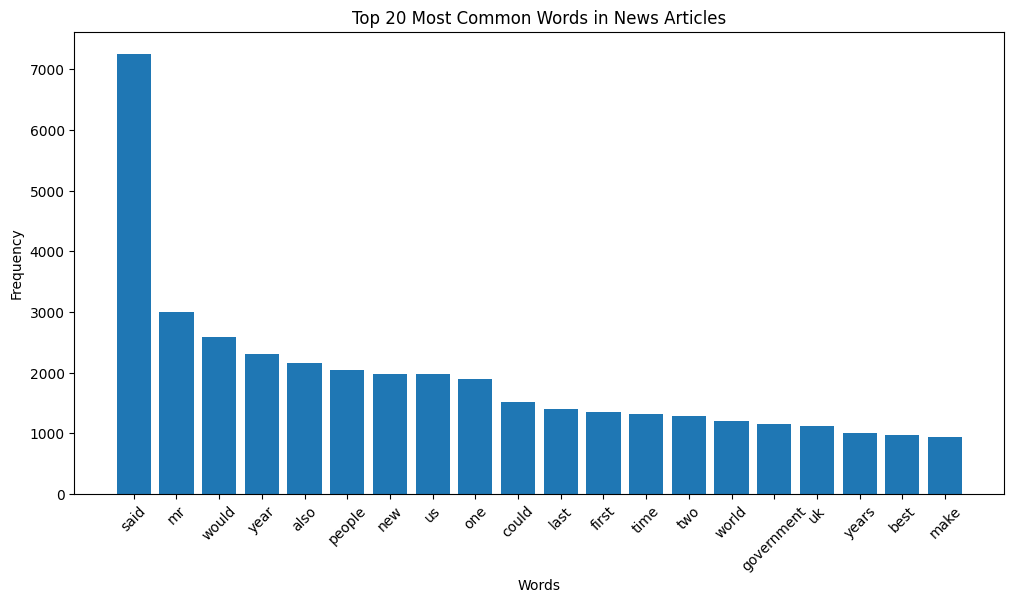

In [13]:
# Plot the 20 most common words

common_words = word_counts.most_common(20)

words = [word for word, count in common_words]
counts = [count for word, count in common_words]

plt.figure(figsize=(12, 6))
plt.bar(words, counts)

plt.title("Top 20 Most Common Words in News Articles")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

## Text Data Analysis – Observations

- The dataset contains **855,598 total word occurrences** and **27,877 unique words**, indicating substantial vocabulary diversity.
- After stopword removal, **27,728 unique words** remain, showing that most unique terms are meaningful content words.
- The average article length is approximately **390 words**, with articles ranging from **90 to 4,492 words**.
- **Technology articles are the longest on average (507 words)**, followed by Politics (461 words), while the other categories average around 334–338 words.
- The most frequent meaningful words include **“said”, “mr”, “would”, “year”, “people”, “new”, and “government”**, reflecting the news-oriented nature of the dataset.
- Overall, the articles contain a wide range of vocabulary and varying lengths, making **text preprocessing and feature extraction important steps** before classification.

## Insights from Exploratory Data Analysis

The EDA provides the following key insights:

- **Category distribution:** Sports (511) and Business (510) are the most represented categories, while Entertainment (386) has the fewest articles. The relatively balanced distribution suggests that the classification models will have sufficient examples from each category.

- **Article length:** The average article contains approximately **390 words**. Technology articles are the longest on average (**507 words**), followed by Politics (**461 words**), suggesting that these categories tend to contain more detailed or explanatory content.

- **Text diversity:** The dataset contains approximately **855,598 word occurrences** and **27,877 unique words**, indicating a large and diverse vocabulary. This highlights the need for effective text representation techniques such as Bag of Words and TF-IDF.

- **Common terminology:** Words such as *said, year, people, new, government,* and *world* occur frequently. These terms reflect the general news-oriented nature of the dataset, while category-specific terminology can help the models distinguish between different types of news.

- **Variation in article complexity:** Article lengths vary considerably, with articles ranging from **90 to 4,492 words**. This indicates that the dataset contains both short news reports and much longer articles.

Overall, the EDA indicates that the dataset contains **diverse and relatively well-distributed textual content**, making it suitable for applying NLP-based multi-class classification techniques.

In [15]:
from collections import Counter
import re

for category in df["Category"].unique():
    text = " ".join(df[df["Category"] == category]["Article"].astype(str)).lower()
    words = re.findall(r"\b[a-zA-Z]{3,}\b", text)

    # Remove stopwords
    category_words = [word for word in words if word not in stop_words]

    print(f"\n{category}")
    print(Counter(category_words).most_common(10))


Technology
[('said', 1567), ('people', 961), ('also', 537), ('one', 534), ('new', 517), ('technology', 504), ('mobile', 494), ('would', 471), ('could', 469), ('users', 408)]

Business
[('said', 1680), ('year', 713), ('would', 464), ('also', 440), ('market', 434), ('new', 417), ('company', 416), ('growth', 385), ('last', 367), ('firm', 362)]

Sports
[('said', 942), ('year', 494), ('first', 484), ('game', 482), ('england', 461), ('time', 423), ('win', 419), ('would', 396), ('two', 394), ('world', 388)]

Entertainment
[('said', 825), ('film', 788), ('best', 619), ('year', 455), ('music', 435), ('also', 398), ('one', 376), ('show', 330), ('new', 323), ('awards', 273)]

Politics
[('said', 2241), ('would', 1054), ('labour', 767), ('government', 732), ('people', 623), ('election', 608), ('party', 586), ('blair', 578), ('also', 452), ('minister', 436)]


## Comments on Text Data

The category-wise keyword analysis reveals clear differences in the vocabulary used across the five news categories:

- **Technology:** Words such as *technology, mobile,* and *users* are prominent, indicating a strong focus on digital products, technology developments, and user-related topics.

- **Business:** Terms such as *market, company, growth,* and *firm* are frequently used, reflecting themes related to companies, financial markets, and business performance.

- **Sports:** Keywords such as *game, England, first, time, win,* and *world* are common, reflecting coverage of sporting events, teams, competitions, and results.

- **Entertainment:** Words such as *film, music, show,* and *awards* occur frequently, indicating a focus on movies, music, television, and entertainment events.

- **Politics:** The presence of terms such as *Labour, government, election, party, Blair,* and *minister* clearly reflects political news and government-related events.

- **Common news terminology:** The word *said* appears frequently across all categories. Other general terms such as *also, would, year, new,* and *people* also occur across multiple categories. These words are common in news reporting and may be less useful for distinguishing categories.

Overall, the analysis shows that each category contains **distinctive domain-specific vocabulary**, while also sharing common news-reporting terms. These category-specific patterns are expected to provide useful signals for the Machine Learning models during text classification.

## Data Preprocessing

Data preprocessing is an important step in preparing the news articles for Machine Learning. Since the primary feature is unstructured textual data, both the dataset structure and the article content need to be cleaned before modeling.

The preprocessing workflow consists of:

1. Checking and removing duplicate records
2. Checking and handling missing values
3. Cleaning the article text
4. Tokenizing the text
5. Removing stopwords
6. Lemmatizing the words
7. Creating useful text-based features
8. Encoding the target variable
9. Splitting the data into training and testing sets
10. Transforming the text into numerical features using Bag of Words or TF-IDF

In [16]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 99


In [17]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2126, 4)


### Duplicate Value Check

The dataset was checked for duplicate records to ensure that the same news article is not unnecessarily represented multiple times.

A total of **99 duplicate records** were identified and removed. Removing duplicates helps prevent repeated articles from influencing the Machine Learning models and provides a cleaner dataset for training and evaluation.

In [18]:
# Install required NLTK resources
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [19]:
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [20]:
# Initialize NLP components
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    """
    Preprocess a news article by:
    1. Converting text to lowercase
    2. Removing non-letter characters
    3. Tokenizing the text
    4. Removing stopwords
    5. Lemmatizing words
    """

    # Convert to lowercase
    text = text.lower()

    # Remove non-letter characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    # Convert tokens back into a single string
    return " ".join(tokens)

In [21]:
# Select one article for demonstration
sample_article = df["Article"].iloc[0]

print("BEFORE PREPROCESSING:\n")
print(sample_article)

print("\n" + "="*100 + "\n")

print("AFTER PREPROCESSING:\n")
print(preprocess_text(sample_article))

BEFORE PREPROCESSING:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also 

In [22]:
# Apply preprocessing to all articles
df["Processed_Article"] = df["Article"].apply(preprocess_text)

# Display the first few rows
df[["Article", "Processed_Article", "Category"]].head()

,Article,Processed_Article,Category
0,tv future in the hands of viewers with home th...,tv future hand viewer home theatre system plas...,Technology
1,worldcom boss left books alone former worldc...,worldcom bos left book alone former worldcom b...,Business
2,tigers wary of farrell gamble leicester say ...,tiger wary farrell gamble leicester say rushed...,Sports
3,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...,Sports
4,ocean s twelve raids box office ocean s twelve...,ocean twelve raid box office ocean twelve crim...,Entertainment


### Text Preprocessing – Observation

The text preprocessing function performs several transformations on the original news articles.

- Non-letter characters are removed to reduce unnecessary noise.
- Text is converted to lowercase to ensure that words with different capitalization are treated consistently.
- Tokenization converts each article into individual words.
- Common English stopwords are removed because they generally provide limited information for classification.
- Lemmatization converts words to their base dictionary form, helping reduce variations of the same word.

As a result, the processed text is cleaner and more suitable for conversion into numerical features for Machine Learning.

In [23]:
# Create text-based features
df["Article_Word_Count"] = df["Article"].apply(lambda x: len(str(x).split()))
df["Article_Char_Count"] = df["Article"].apply(len)

df[["Category", "Article_Word_Count", "Article_Char_Count"]].head()

,Category,Article_Word_Count,Article_Char_Count
0,Technology,737,4333
1,Business,300,1842
2,Sports,246,1342
3,Sports,341,2176
4,Entertainment,260,1579


### Feature Engineering

In addition to the processed text, article length features were created to capture basic characteristics of the news articles.

- `Article_Word_Count` represents the number of words in an article.
- `Article_Char_Count` represents the total number of characters.

These features provide additional information about the structure and length of the articles. However, the primary features for classification will be the numerical representations generated from the processed text.

In [24]:
from sklearn.preprocessing import LabelEncoder

# Initialize Label Encoder
label_encoder = LabelEncoder()

# Encode the target variable
df["Category_Encoded"] = label_encoder.fit_transform(df["Category"])

# Display the mapping
category_mapping = dict(
    zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
)

print("Category Encoding:")
print(category_mapping)

Category Encoding:
{'Business': np.int64(0), 'Entertainment': np.int64(1), 'Politics': np.int64(2), 'Sports': np.int64(3), 'Technology': np.int64(4)}


### Target Variable Encoding

The categorical target variable `Category` was converted into numerical labels using `LabelEncoder`.

Each news category is assigned a unique numerical value, allowing the Machine Learning algorithms to process the target variable.

The encoding is performed only on the target variable; the textual article content will be transformed separately using Bag of Words or TF-IDF.

In [25]:
from sklearn.model_selection import train_test_split

# Features and target
X = df["Processed_Article"]
y = df["Category_Encoded"]

# 75:25 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1594,)
Testing data shape: (532,)


In [26]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Choose vectorization technique
vectorization_method = "tfidf"   # Change to "bow" for Bag of Words

if vectorization_method.lower() == "bow":
    vectorizer = CountVectorizer()

elif vectorization_method.lower() == "tfidf":
    vectorizer = TfidfVectorizer()

else:
    raise ValueError("Choose either 'bow' or 'tfidf'.")

# Fit only on training data
X_train_vectorized = vectorizer.fit_transform(X_train)

# Transform test data using the fitted vectorizer
X_test_vectorized = vectorizer.transform(X_test)

print("Vectorization method:", vectorization_method.upper())
print("Training feature shape:", X_train_vectorized.shape)
print("Testing feature shape:", X_test_vectorized.shape)

Vectorization method: TFIDF
Training feature shape: (1594, 22093)
Testing feature shape: (532, 22093)


### Text Vectorization

Machine Learning algorithms require numerical input, so the processed text must be converted into numerical feature vectors.

Two commonly used approaches are considered:

- **Bag of Words (BoW):** Represents each article using the frequency of words appearing in the document.
- **TF-IDF:** Assigns weights to words based on their importance within an article relative to the entire collection of articles.

The notebook provides an option to switch between the two techniques. The vectorizer is fitted only on the training data and then applied to the test data to prevent data leakage.

### Patterns Identified in Text Data

The EDA showed that the dataset contains a diverse vocabulary of approximately **27,877 unique words** and substantial variation in article length.

Category-specific vocabulary is also evident. For example, Technology articles frequently contain terms such as *mobile, technology,* and *users*, while Business articles contain terms such as *market, company,* and *growth*. Sports articles frequently use terms such as *game, win,* and *England*, whereas Politics articles contain terms such as *government, election, party,* and *minister*.

At the same time, common news-reporting terms such as *said, would, year,* and *also* occur across multiple categories. This overlap reinforces the importance of using appropriate text preprocessing and feature extraction techniques to identify informative terms.

The relatively balanced category distribution and presence of distinctive category-specific vocabulary indicate that the dataset is suitable for multi-class text classification.

## Preprocessing and Data Preparation – Observations

- **Text cleaning:** The sample article shows a clear reduction in noise after preprocessing, with punctuation, special characters, and other non-letter elements removed.

- **Tokenization and stopword removal:** The text is converted into individual meaningful words, while common English stopwords are removed to reduce unnecessary information.

- **Lemmatization:** Words are converted to their base forms, such as *viewers → viewer*, *technologies → technology*, and *programmes → programme*. This helps reduce different forms of the same word.

- **Target encoding:** The five categories were successfully encoded into numerical labels, allowing them to be used by Machine Learning algorithms.

- **Train-test split:** A 75:25 split resulted in **1,594 training articles** and **532 testing articles**. Stratified splitting was used to maintain the category distribution across both datasets.

- **TF-IDF vectorization:** The processed articles were transformed into **22,093 numerical features**. Both training and testing datasets have the same number of features, as expected.

- **Feature representation:** TF-IDF was selected for the current modeling pipeline because it gives greater importance to terms that are informative within individual articles while reducing the influence of very common terms.

Overall, the preprocessing successfully converts the raw news articles into a **clean, standardized, and numerical representation suitable for Machine Learning classification**.

In [27]:
# Model Building

from sklearn.naive_bayes import MultinomialNB

# Initialize the Naive Bayes classifier
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_vectorized, y_train)

# Generate predictions on the test data
y_pred_nb = nb_model.predict(X_test_vectorized)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [28]:
# Model Building - Naive Bayes Evaluation

from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", round(nb_accuracy, 4))

# Display classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=label_encoder.classes_
    )
)

Naive Bayes Accuracy: 0.9586

Classification Report:
               precision    recall  f1-score   support

     Business       0.92      1.00      0.96       126
Entertainment       0.99      0.89      0.94        92
     Politics       0.93      0.97      0.95       101
       Sports       0.98      1.00      0.99       126
   Technology       1.00      0.90      0.95        87

     accuracy                           0.96       532
    macro avg       0.96      0.95      0.96       532
 weighted avg       0.96      0.96      0.96       532



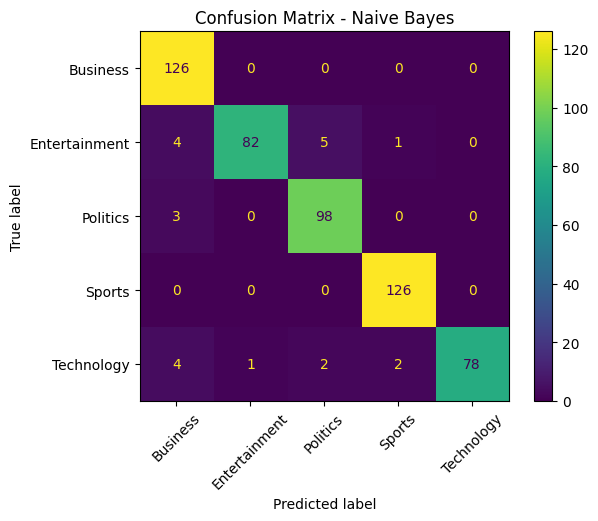

In [29]:
# Model Building - Naive Bayes Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

## Model Building – Naive Bayes: Observations

The **Multinomial Naive Bayes** model achieved an overall accuracy of **95.86%**, indicating strong performance in classifying the news articles.

- **Sports** achieved the strongest performance, with **98% precision, 100% recall, and 99% F1-score**. All 126 Sports articles in the test set were correctly classified.
- **Business** achieved **100% recall**, meaning all Business articles were correctly identified, although a few articles from other categories were incorrectly classified as Business.
- **Entertainment** had **89% recall**, indicating that some Entertainment articles were misclassified, mainly as Business and Politics.
- **Politics** performed strongly with **97% recall** and **95% F1-score**.
- **Technology** achieved **100% precision** but **90% recall**, meaning that when the model predicted Technology it was always correct, but some Technology articles were classified into other categories.

The confusion matrix shows that most predictions lie along the diagonal, indicating a high number of correct classifications. The relatively small number of off-diagonal predictions suggests that the TF-IDF features capture strong category-specific patterns.

Overall, Naive Bayes provides a **strong baseline model with balanced precision and recall**, achieving an F1-score of approximately **0.96** across the five categories.

## Hyperparameter Tuning

Hyperparameter tuning is performed to identify parameter combinations that can improve model performance.

`GridSearchCV` is used to systematically evaluate different combinations of hyperparameters using cross-validation. The models are optimized using **F1-macro**, which gives equal importance to each news category and considers both precision and recall.

The following models will be tuned:

- Naive Bayes – smoothing parameter (`alpha`)
- Decision Tree – tree depth and minimum samples
- Random Forest – number of trees, tree depth, and minimum samples

The best parameters identified through cross-validation will then be used to train the final models.

In [30]:
# Hyperparameter Tuning - Naive Bayes

from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

# Define model
nb = MultinomialNB()

# Define hyperparameter grid
nb_param_grid = {
    "alpha": [0.01, 0.1, 0.5, 1.0, 2.0]
}

# Grid Search
nb_grid = GridSearchCV(
    estimator=nb,
    param_grid=nb_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

# Fit on training data
nb_grid.fit(X_train_vectorized, y_train)

print("Best Naive Bayes parameters:", nb_grid.best_params_)
print("Best CV F1-score:", round(nb_grid.best_score_, 4))

Best Naive Bayes parameters: {'alpha': 0.1}
Best CV F1-score: 0.9718


In [31]:
# Hyperparameter Tuning - Decision Tree

from sklearn.tree import DecisionTreeClassifier

# Define model
dt = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
dt_param_grid = {
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

# Grid Search
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

# Fit on training data
dt_grid.fit(X_train_vectorized, y_train)

print("Best Decision Tree parameters:", dt_grid.best_params_)
print("Best CV F1-score:", round(dt_grid.best_score_, 4))

Best Decision Tree parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-score: 0.8005


In [33]:
# Hyperparameter Tuning - Random Forest

from sklearn.ensemble import RandomForestClassifier

# Define model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Define hyperparameter grid
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid Search
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

# Fit on training data
rf_grid.fit(X_train_vectorized, y_train)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best CV F1-score:", round(rf_grid.best_score_, 4))

Best Random Forest parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-score: 0.9615


In [34]:
# Hyperparameter Tuning - Test Set Evaluation

from sklearn.metrics import accuracy_score, classification_report

# Best models selected by GridSearchCV
best_nb = nb_grid.best_estimator_
best_dt = dt_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Predictions
y_pred_nb_tuned = best_nb.predict(X_test_vectorized)
y_pred_dt_tuned = best_dt.predict(X_test_vectorized)
y_pred_rf_tuned = best_rf.predict(X_test_vectorized)

# Test accuracies
print("Tuned Naive Bayes Accuracy:",
      round(accuracy_score(y_test, y_pred_nb_tuned), 4))

print("Tuned Decision Tree Accuracy:",
      round(accuracy_score(y_test, y_pred_dt_tuned), 4))

print("Tuned Random Forest Accuracy:",
      round(accuracy_score(y_test, y_pred_rf_tuned), 4))

Tuned Naive Bayes Accuracy: 0.9718
Tuned Decision Tree Accuracy: 0.8252
Tuned Random Forest Accuracy: 0.968


In [35]:
# Hyperparameter Tuning - Classification Reports

models = {
    "Tuned Naive Bayes": y_pred_nb_tuned,
    "Tuned Decision Tree": y_pred_dt_tuned,
    "Tuned Random Forest": y_pred_rf_tuned
}

for model_name, predictions in models.items():
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(
        y_test,
        predictions,
        target_names=label_encoder.classes_
    ))


Tuned Naive Bayes
               precision    recall  f1-score   support

     Business       0.96      0.98      0.97       126
Entertainment       0.98      0.96      0.97        92
     Politics       0.96      0.98      0.97       101
       Sports       1.00      0.99      1.00       126
   Technology       0.95      0.94      0.95        87

     accuracy                           0.97       532
    macro avg       0.97      0.97      0.97       532
 weighted avg       0.97      0.97      0.97       532


Tuned Decision Tree
               precision    recall  f1-score   support

     Business       0.77      0.82      0.80       126
Entertainment       0.82      0.82      0.82        92
     Politics       0.84      0.78      0.81       101
       Sports       0.87      0.91      0.89       126
   Technology       0.82      0.77      0.79        87

     accuracy                           0.83       532
    macro avg       0.83      0.82      0.82       532
 weighted avg       

## Hyperparameter Tuning – Observations

Hyperparameter tuning produced different results across the three models.

- **Naive Bayes** showed the most significant improvement. The best value of `alpha` was **0.1**, increasing test accuracy from **95.86% to 97.18%**. Its macro F1-score also reached **0.97**, indicating strong and balanced performance across all categories.

- **Random Forest** performed strongly after tuning, achieving **96.80% accuracy** with **200 trees** and `min_samples_split=5`. Its macro F1-score was approximately **0.97**, making it competitive with Naive Bayes.

- **Decision Tree** performed considerably worse, achieving only **82.52% accuracy**. Its macro F1-score of **0.82** indicates that it was less effective at capturing the complex patterns present in the high-dimensional text data.

- Overall, **Naive Bayes was the best-performing model after hyperparameter tuning**, achieving the highest test accuracy (**97.18%**) and strong precision, recall, and F1-scores across all five categories.

The results demonstrate that hyperparameter tuning can improve model performance, although the extent of improvement depends heavily on the underlying algorithm.

## Model Performance Comparison

| Model | Accuracy | Macro F1-Score |
|---|---:|---:|
| Naive Bayes – Before Tuning | 95.86% | 0.96 |
| Naive Bayes – After Tuning | **97.18%** | **0.97** |
| Decision Tree – Tuned | 82.52% | 0.82 |
| Random Forest – Tuned | 96.80% | 0.97 |

**Key finding:** Tuned Naive Bayes achieved the highest test accuracy of **97.18%**, while Random Forest was a close second at **96.80%**. Decision Tree performed substantially worse than the other models on the TF-IDF feature representation.

## Handling Text Data Specifics

Text data presents unique challenges because news articles contain a large vocabulary, resulting in a high-dimensional feature space. In this dataset, the TF-IDF representation generated **22,093 features** from only 1,594 training articles.

### Feature Representation

Two common approaches were considered:

- **Bag of Words (BoW):** Represents each document using the frequency of individual words.
- **TF-IDF:** Weights words according to their importance within a document while reducing the influence of words that occur frequently across many documents.

TF-IDF was used for the primary modeling pipeline because it is well suited to text classification and helps reduce the influence of common terms while emphasizing more informative words.

### Dimensionality

The large number of features compared with the number of training articles demonstrates the high-dimensional nature of the dataset. Many of these features are sparse, meaning that a particular article contains only a small subset of the overall vocabulary.

### Regularization and Overfitting

High-dimensional text data can increase the risk of overfitting, particularly for complex models. Model-specific controls such as tree depth, minimum samples per split, minimum samples per leaf, and the number of trees were considered during hyperparameter tuning.

Cross-validation through `GridSearchCV` was used to select suitable hyperparameters based on **macro F1-score**, helping identify models that generalize well across all five categories.

Overall, TF-IDF combined with appropriate model parameters provides an effective way to handle the high-dimensional and sparse nature of the news article data.

In [37]:
# Handling Text Data Specifics

# Calculate sparsity of the TF-IDF training matrix
total_elements = X_train_vectorized.shape[0] * X_train_vectorized.shape[1]
non_zero_elements = X_train_vectorized.nnz

sparsity = 1 - (non_zero_elements / total_elements)

print("Number of training articles:", X_train_vectorized.shape[0])
print("Number of TF-IDF features:", X_train_vectorized.shape[1])
print("Non-zero elements:", non_zero_elements)
print("Sparsity:", round(sparsity * 100, 2), "%")

Number of training articles: 1594
Number of TF-IDF features: 22093
Non-zero elements: 236446
Sparsity: 99.33 %


## Incorporating Advanced Models

After establishing strong baseline results using traditional Machine Learning algorithms, an advanced NLP approach using a pre-trained **BERT** model can be explored.

Traditional approaches such as TF-IDF represent text primarily through individual words and their statistical importance. In contrast, transformer-based models such as BERT use contextual representations and can capture relationships between words based on their surrounding context.

For this experiment, a pre-trained BERT model can be fine-tuned on the FlipItNews dataset for multi-class news classification.

The purpose of this experiment is not only to obtain a higher accuracy, but also to determine whether contextual representations provide a meaningful advantage over the simpler TF-IDF-based models.

The BERT model will be evaluated using the same metrics as the traditional models:
- Accuracy
- Precision
- Recall
- F1-score

The final model selection will consider both predictive performance and model complexity.

In [38]:
# Incorporating Advanced Models - Install Libraries

!pip -q install transformers datasets accelerate

In [59]:
# Incorporating Advanced Models - Prepare BERT Dataset

from datasets import Dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

# Create datasets
train_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

test_df = pd.DataFrame({
    "text": X_test.values,
    "label": y_test.values
})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

# Remove original text column
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

# Dynamic padding
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("BERT datasets prepared successfully.")

Map:   0%|          | 0/1594 [00:00<?, ? examples/s]

Map:   0%|          | 0/532 [00:00<?, ? examples/s]

BERT datasets prepared successfully.


In [60]:
# Incorporating Advanced Models - Create BERT Trainer

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer created successfully.")

Trainer created successfully.


In [61]:
# Incorporating Advanced Models - Train BERT

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.091773,0.983083,0.981727,0.983044,0.982311
2,No log,0.127987,0.977444,0.977400,0.976978,0.977073
3,0.202677,0.111731,0.979323,0.978464,0.978765,0.978579


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=600, training_loss=0.17473377108573915, metrics={'train_runtime': 315.3092, 'train_samples_per_second': 15.166, 'train_steps_per_second': 1.903, 'total_flos': 627993115304976.0, 'train_loss': 0.17473377108573915, 'epoch': 3.0})

## Model Evaluation

### Evaluation Metrics

| Metric | Purpose |
|---|---|
| **Accuracy** | Measures the overall proportion of correctly classified articles. |
| **Precision** | Measures how accurately the model assigns articles to each predicted category. |
| **Recall** | Measures how well the model identifies articles that actually belong to each category. |
| **F1-Score** | Provides a balance between precision and recall. |
| **Macro F1-Score** | Gives equal importance to every category and is useful for comparing performance across all five news categories. |

For this multiclass classification problem, **accuracy, precision, recall, and F1-score** are considered together. Macro F1-score is particularly useful because it prevents the performance on larger categories from dominating the overall evaluation.

### Multiple Model Comparison

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| Naive Bayes | 95.86% | 96.00% | 95.00% | 96.00% |
| Tuned Naive Bayes | **97.18%** | **97.00%** | **97.00%** | **97.00%** |
| Tuned Decision Tree | 82.52% | 83.00% | 82.00% | 82.00% |
| Tuned Random Forest | 96.80% | 97.00% | 96.00% | 97.00% |
| **BERT (Best Epoch)** | **98.31%** | **98.17%** | **98.30%** | **98.23%** |

### Comparison and Findings

- **BERT achieved the best overall performance**, with 98.31% validation accuracy and a 98.23% F1-score.
- **Tuned Naive Bayes** was the strongest classical model, achieving 97.18% accuracy.
- **Random Forest** also performed strongly at 96.80% accuracy.
- **Decision Tree** performed substantially worse, with 82.52% accuracy, indicating that a single tree was less effective for the high-dimensional text representation.
- BERT's high precision and recall indicate that it performs consistently across the five news categories rather than relying only on the more represented categories.
- Overall, the results demonstrate that both **TF-IDF-based classical models and contextual BERT representations** can classify the news articles effectively, with BERT providing the best performance.

# Results Interpretation & Stakeholder Presentation

## A. Business Context

FlipItNews aims to improve how users discover relevant financial, business, and general news content. Accurate categorization can improve **content relevance, discoverability, user engagement, and category diversification**.

The classification results show that automated categorization can reliably organize articles into Politics, Technology, Sports, Business, and Entertainment, providing a strong foundation for personalized feeds and improved content discovery.

## B. Interpretation of Model Results

The models were evaluated using accuracy, precision, recall, and F1-score.

| Model | Accuracy | Macro F1 | Interpretation |
|---|---:|---:|---|
| Naive Bayes | 95.86% | ~96% | Strong baseline for text classification |
| Tuned Naive Bayes | 97.18% | ~97% | Best classical model |
| Tuned Decision Tree | 82.52% | ~82% | Significantly weaker for this text data |
| Tuned Random Forest | 96.80% | ~97% | Strong performance, close to Naive Bayes |
| BERT – Best Epoch | **98.31%** | **98.23%** | **Best overall performance** |

BERT achieved the highest validation performance, indicating that contextual language representations can capture useful relationships in news content beyond traditional TF-IDF features.

The strong precision and recall across categories also indicate that the model can identify relevant articles without excessively misclassifying articles from other categories.

## C. Visual Representation

The following visualizations help stakeholders understand model performance:

- **Confusion Matrix:** Shows correct classifications and category-level misclassifications.
- **Model Accuracy Comparison:** Highlights differences in overall model performance.
- **Category-wise Precision, Recall and F1-score:** Shows whether performance is consistent across individual news categories.

These visualizations make the results easier to interpret and help identify categories that may require further improvement.

## D. Trade-off Analysis

| Decision | Benefit | Trade-off |
|---|---|---|
| TF-IDF | Efficient and effective representation for classical models | Does not capture deeper contextual meaning |
| Naive Bayes | Fast, simple, and highly effective for text | Makes strong independence assumptions |
| Random Forest | Robust ensemble model | More computationally expensive than Naive Bayes |
| Decision Tree | Simple and interpretable | Poorer performance on high-dimensional text |
| BERT | Best performance and contextual understanding | Requires substantially more computational resources and training time |

The results show that **higher model complexity does not always guarantee better performance**. Tuned Naive Bayes achieved 97.18% accuracy while remaining considerably simpler than BERT. BERT improved performance further to 98.31%, but at a higher computational cost.

## E. Recommendations

1. **Adopt BERT for applications where maximum classification accuracy is important**, particularly for production systems with sufficient computational resources.
2. **Retain Tuned Naive Bayes as a lightweight baseline or fallback model**, as it provides 97.18% accuracy with much lower complexity.
3. **Use category-wise monitoring** to identify categories where precision or recall decreases over time.
4. **Expand and regularly refresh the training dataset** with newer news articles to handle changes in topics, terminology, and writing styles.
5. **Use user feedback and engagement signals** to identify incorrectly categorized or poorly relevant content.
6. **Monitor category distribution** to ensure that recommendations do not become overly concentrated in a small number of categories.

## F. Feedback Loop and Continuous Improvement

A continuous feedback loop can improve the categorization system over time:

**New Articles → Model Prediction → User Engagement/Feedback → Error Analysis → New Training Data → Model Retraining → Evaluation**

The model should be periodically evaluated using newly collected articles. Misclassified articles and user feedback can be incorporated into future training cycles. This will help the system adapt to emerging topics, new terminology, and changes in news patterns.

---

# Questionnaire

## 1. How many news articles are present in the dataset?

**Answer: 2,225 news articles**

The dataset contains 2,225 articles across five categories.

## 2. Most of the news articles are from _____ category.

**Answer: Sports**

| Category | Number of Articles |
|---|---:|
| Sports | **511** |
| Business | 510 |
| Politics | 417 |
| Technology | 401 |
| Entertainment | 386 |

Sports is the most represented category, although the difference from Business is only one article.

## 3. Only ___ no. of articles belong to the Technology category.

**Answer: 401 articles**

Technology contains 401 articles, making it the fourth-largest category in the dataset.

## 4. What are Stop Words and why should they be removed from the text data?

**Answer:** Stop words are frequently occurring words such as *the, is, and, of, to,* and *in* that generally contribute limited information for text classification.

Removing them can:

- Reduce unnecessary words and noise.
- Reduce the number of features.
- Improve computational efficiency.
- Allow the model to focus more on informative words.

## 5. Explain the difference between Stemming and Lemmatization.

| Stemming | Lemmatization |
|---|---|
| Removes word endings using simpler rules | Converts words to their meaningful base form |
| Can produce non-dictionary words | Produces valid dictionary forms |
| Faster | Usually more computationally intensive |
| Example: `studies → studi` | Example: `studies → study` |

**Lemmatization** was used in this case study because it produces more meaningful normalized words.

## 6. Which of the techniques Bag of Words or TF-IDF is considered to be more efficient?

**Answer: TF-IDF is generally more informative for this use case.**

Bag of Words represents words primarily by their frequency, whereas TF-IDF reduces the importance of words that occur frequently across many documents and gives more weight to terms that are distinctive to particular documents.

For this case study, TF-IDF produced a high-dimensional but sparse representation of the articles and performed well with the classical classification models.

## 7. What's the shape of train & test data sets after performing a 75:25 split?

| Dataset | Shape |
|---|---|
| Training data | **(1594,)** |
| Testing data | **(532,)** |

The split was performed using stratification to preserve the category distribution between training and testing sets.

## 8. Which is the best-performing model?

Among the listed options:

**Answer: c. Naive Bayes**

The **Tuned Naive Bayes** model achieved **97.18% accuracy**, outperforming the tuned Random Forest at 96.80%.

> Note: The advanced BERT experiment achieved a higher validation accuracy of **98.31%**, but BERT is not one of the options in this questionnaire.

## 9. According to this particular use case, both precision and recall are equally important. (T/F)

**Answer: True (T)**

Both metrics are important because FlipItNews needs to:

- **Precision:** Ensure that articles assigned to a category are actually relevant to that category.
- **Recall:** Ensure that relevant articles belonging to a category are not missed.

Therefore, evaluating both precision and recall provides a more complete assessment than accuracy alone.

# Conclusion

This case study demonstrated how Natural Language Processing and machine learning can be used to automatically classify news articles into **Business, Entertainment, Politics, Sports, and Technology** categories.

The dataset contained **2,225 articles** and was successfully preprocessed using text cleaning, tokenization, stopword removal, and lemmatization. TF-IDF was then used to convert the textual data into numerical features for classical machine learning models.

Among the classical models, **Tuned Naive Bayes performed best with 97.18% accuracy**, followed closely by Random Forest at 96.80%. Decision Tree performed considerably lower at 82.52%. The advanced **BERT model achieved the highest validation performance of 98.31% accuracy and 98.23% F1-score**, demonstrating the value of contextual language representations.

Overall, the results show that automated news categorization can achieve high accuracy and can support FlipItNews in improving **content relevance, discovery, personalization, and user engagement**. Future improvements can focus on expanding the dataset, continuously incorporating new articles and user feedback, monitoring category-wise performance, and periodically retraining the model to adapt to changing news trends and vocabulary.

In [62]:
#

In [63]:
#

In [66]:
#

In [67]:
#

In [68]:
#

In [69]:
#

In [70]:
#

In [71]:
#

In [72]:
#

In [73]:
#

In [74]:
#

In [75]:
#

In [76]:
#

In [77]:
#

In [78]:
#

In [79]:
#

In [80]:
#

In [81]:
#

In [82]:
#

In [83]:
#

In [84]:
#

In [87]:
#

In [88]:
#